# Phase 1 all — 실험 결과 종합 분석

**분석 대상:** `results/phase1_ver3/{dataset}/{method}/`

**데이터셋:** HumanEval, MBPP  
**방법:** single_shot, retry_only, repair_loop, code_then_plan, code_then_plan_repair

---
## 목차
1. 데이터 로드
2. 핵심 지표 비교 (pass@1, exec_success_rate, conditional_pass)
3. 방법별 비교 시각화
4. Failure Type 분석
5. Transition Path 분석 (retry / repair)
6. 토큰 / 레이턴시 효율성 분석
7. Step-level 상세 분석
8. Failure Breakdown

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──
nanum = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
noto  = [f.fname for f in fm.fontManager.ttflist if 'NotoSansCJK' in f.name or 'Noto Sans CJK' in f.name]

if nanum:
    plt.rcParams['font.family'] = 'NanumGothic'
elif noto:
    plt.rcParams['font.family'] = 'Noto Sans CJK KR'
else:
    print('⚠️ 한국어 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.')

plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..'))
RESULTS_ROOT  = os.path.join(PROJECT_ROOT, 'results', 'phase2_qwen')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS_ROOT : {RESULTS_ROOT}')

# ── 스타일 설정 ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── 상수 ──
DATASETS = ['humaneval_fin']
# METHODS  = ['single', 'retry', 'repair','code_then_plan','code_then_plan_repair','policy_loop']
METHODS  = ['single','repair','code_then_plan','code_then_plan_repair','rpe_policy','rpe_policy_v2']
METHOD_LABELS = {
    'single'   : 'Single Shot',
    'repair'   : 'Repair Loop',
    'planner_coder' : 'Planner-Coder',
    'code_then_plan' : 'Code-Then-Plan',
    'code_then_replan' : 'Code-Then-Replan',
    'code_then_plan_repair' : 'Code-Then-Plan+Repair',
    'rpe_policy' : 'Policy Loop'
}

# ── 색상 팔레트 ──
METHOD_COLORS = {
    'single'        : '#4C72B0',
    'repair'       : '#55A868',
    'planner_coder'        : '#C44E52',
    'code_then_plan' : '#8172B2',
    'code_then_replan' : '#9EDDFF',
    'code_then_plan_repair' : '#DD8452',
    'rpe_policy' : '#FFA500'
}

PROJECT_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration
RESULTS_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration/results/phase2_qwen


---
## 1. 데이터 로드

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# ── 결과 로드 ──
summaries          = {}   # (dataset, method) -> summary dict
analyses           = {}   # (dataset, method) -> analysis dict
step_logs_all      = {}   # (dataset, method) -> list of step records
traj_logs_all      = {}   # (dataset, method) -> list of trajectory records
failure_examples_all = {} # (dataset, method) -> dict of failure examples

found = []
missing = []

for dataset in DATASETS:
    for method in METHODS:
        base = os.path.join(RESULTS_ROOT, dataset, method)
        summary_path = os.path.join(base, 'summary.json')
        if os.path.exists(summary_path):
            key = (dataset, method)
            summaries[key]     = load_json(summary_path)
            # analyses[key]      = load_json(os.path.join(base, 'analysis.json'))
            step_logs_all[key] = load_jsonl(os.path.join(base, 'step_logs.jsonl'))
            traj_logs_all[key] = load_jsonl(os.path.join(base, 'trajectory_logs.jsonl'))
            
            fe_path = os.path.join(base, 'failure_examples.json')
            if os.path.exists(fe_path):
                failure_examples_all[key] = load_json(fe_path)
            
            found.append(f'{dataset}/{method}')
        else:
            missing.append(f'{dataset}/{method}')

print(f'✅ 로드 성공 ({len(found)}개):', ', '.join(found))
if missing:
    print(f'⚠️  결과 없음 ({len(missing)}개):', ', '.join(missing))

✅ 로드 성공 (6개): humaneval_fin/single, humaneval_fin/repair, humaneval_fin/code_then_plan, humaneval_fin/code_then_plan_repair, humaneval_fin/rpe_policy, humaneval_fin/rpe_policy_v2


In [3]:
# ── summary DataFrame 구성 ──
rows = []

for (dataset, method), s in summaries.items():
    if s is None:
        continue

    max_calls = s.get("max_calls", 10)
    success_key = s.get("success_metric_name", f"success@{max_calls}")

    row = {
        "dataset": dataset,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),

        "total": s.get("total_problems", s.get("total", 0)),

        # 기존 num_pass/pass@1 대신 success 계열 사용
        "num_success": s.get("num_success", s.get("success", s.get("num_pass", s.get("passed", 0)))),

        "success_metric_name": success_key,
        "success@k": s.get(
            "success_at_k",
            s.get(success_key, s.get("pass_at_1", s.get("pass@1", 0.0)))
        ),

        "execution_success_rate": s.get("execution_success_rate", 0.0),

        # 기존 conditional_pass와 새 conditional_success 둘 다 대응
        "conditional_success": s.get(
            "conditional_success",
            s.get("conditional_pass", 0.0)
        ),

        "avg_tokens": s.get("avg_tokens", 0.0),
        "avg_latency": s.get("avg_latency", 0.0),
        "avg_calls": s.get("avg_calls", 0.0),
    }

    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(["dataset", "method"])

# 방법 순서 고정
method_order = [
    m for m in METHODS
    if m in df_summary.index.get_level_values("method").unique()
]

print("\n=== Summary DataFrame ===")
display(
    df_summary[
        [
            "total",
            "num_success",
            "success_metric_name",
            "success@k",
            "execution_success_rate",
            "conditional_success",
            "avg_tokens",
            "avg_latency",
            "avg_calls",
        ]
    ].round(4)
)


=== Summary DataFrame ===


total  num_success success_metric_name  \
dataset       method                                                          
humaneval_fin single                   164          114           success@1   
              repair                   164          140          success@10   
              code_then_plan           164          150          success@10   
              code_then_plan_repair    164          151          success@10   
              rpe_policy               164          154          success@10   
              rpe_policy_v2            164          151          success@10   

                                     success@k  execution_success_rate  \
dataset       method                                                     
humaneval_fin single                    0.6951                  0.8476   
              repair                    0.8537                  0.8902   
              code_then_plan            0.9146                  0.9939   
              code_then_plan_repair     0.9207                  0.9573   
              rpe_policy                0.9390                  0.9817   
              rpe_policy_v2             0.9207                  0.9939   

                                     conditional_success  avg_tokens  \
dataset       method                                                   
humaneval_fin single                              0.8201    310.6768   
              repair                              0.9589   1841.0671   
              code_then_plan                      0.9202    735.6524   
              code_then_plan_repair               0.9618    908.7988   
              rpe_policy                          0.9565      0.0000   
              rpe_policy_v2                       0.9264      0.0000   

                                     avg_latency  avg_calls  
dataset       method                                         
humaneval_fin single                      2.4059     1.0000  
              repair                      8.0875     2.7073  
              code_then_plan              3.5982     2.2439  
              code_then_plan_repair       4.2419     2.5061  
              rpe_policy                  0.0000     0.0000  
              rpe_policy_v2               0.0000     0.0000

---
## 2. 핵심 지표 비교표

In [4]:
METRICS = ['success@k', 'execution_success_rate', 'conditional_success']
METRIC_LABELS = {
    'success@k'            : 'Success@K',
    'execution_success_rate' : 'Execution Success Rate',
    'conditional_success'  : 'Conditional Success',
}

for dataset in DATASETS:
    if dataset not in df_summary.index.get_level_values('dataset'):
        continue
    sub = df_summary.loc[dataset, METRICS].copy()
    # 방법 순서 정렬
    sub = sub.reindex([m for m in METHODS if m in sub.index])
    sub.index = [METHOD_LABELS.get(m, m) for m in sub.index]
    sub.columns = [METRIC_LABELS[c] for c in sub.columns]

    print(f'\n=== {dataset.upper()} ========================')
    display(sub.style
               .format('{:.4f}')
               .background_gradient(cmap='YlGn', axis=0))


=== HUMANEVAL_FIN ========================


,Success@K,Execution Success Rate,Conditional Success
Single Shot,0.6951,0.8476,0.8201
Repair Loop,0.8537,0.8902,0.9589
Code-Then-Plan,0.9146,0.9939,0.9202
Code-Then-Plan+Repair,0.9207,0.9573,0.9618
Policy Loop,0.9390,0.9817,0.9565
rpe_policy_v2,0.9207,0.9939,0.9264


---
## 4. Failure Type 분석

In [5]:
# analysis.json의 failure_type_counts 수집
failure_rows = []
for (dataset, method), an in analyses.items():
    if an is None:
        continue
    ftc = an.get('failure_type_counts', {})
    for status, cnt in ftc.items():
        # coarse prefix (EXEC_FAIL / TEST_FAIL)
        coarse = status.split(':')[0]
        failure_rows.append({
            'dataset': dataset,
            'method' : method,
            'status' : status,
            'coarse' : coarse,
            'count'  : cnt,
        })

df_failure = pd.DataFrame(failure_rows)

if df_failure.empty:
    print('⚠️  failure_type_counts 데이터가 없습니다.')
else:
    for dataset in DATASETS:
        sub = df_failure[df_failure['dataset'] == dataset]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'coarse'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in METHODS if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        pivot.plot(kind='bar', figsize=(10, 4), edgecolor='white',
                   title=f'{dataset.upper()} — Failure Type (Coarse) 분포',
                   color=['#C44E52', '#DD8452', '#4C72B0'])
        plt.xticks(rotation=15, ha='right')
        plt.ylabel('Step 수 (누적)')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f'fig_failure_coarse_{dataset}.png', bbox_inches='tight', dpi=150)
        plt.show()

        print(f'\n[{dataset.upper()}] Coarse Failure Counts:')
        display(pivot)

⚠️  failure_type_counts 데이터가 없습니다.


In [6]:
# Fine-grained failure type (전체 status 기준)
if not df_failure.empty:
    for dataset in DATASETS:
        sub = df_failure[df_failure['dataset'] == dataset]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'status'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in METHODS if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        print(f'\n[{dataset.upper()}] Fine-grained Failure Counts:')
        display(pivot.style.background_gradient(cmap='Reds', axis=None))

---
## 5. Transition Path 분석

In [7]:
# analysis.json의 transition_counts 수집
trans_rows = []
for (dataset, method), an in analyses.items():
    if an is None:
        continue
    tc = an.get('transition_counts', {})
    for trans, cnt in tc.items():
        trans_rows.append({
            'dataset'    : dataset,
            'method'     : method,
            'transition' : trans,
            'count'      : cnt,
        })

df_trans = pd.DataFrame(trans_rows)

if df_trans.empty:
    print('⚠️  transition_counts 데이터가 없습니다.')
else:
    # 방법별로 의미 있는 것: retry / repair / bestofn
    iterative_methods = ['retry', 'repair', 'bestofn','planner_coder']
    for dataset in DATASETS:
        sub = df_trans[(df_trans['dataset'] == dataset) &
                       (df_trans['method'].isin(iterative_methods))]
        if sub.empty:
            continue

        pivot = sub.groupby(['method', 'transition'])['count'].sum().unstack(fill_value=0)
        pivot = pivot.reindex([m for m in iterative_methods if m in pivot.index])
        pivot.index = [METHOD_LABELS.get(m, m) for m in pivot.index]

        print(f'\n[{dataset.upper()}] Transition Counts (retry/repair/bestofn/planner_coder):')
        display(pivot.style.background_gradient(cmap='Blues', axis=None))

        # 핵심 전이: *→PASS (성공 전이)
        success_trans = [c for c in pivot.columns if c.endswith('->PASS')]
        if success_trans:
            print(f'  → PASS 전이 (복구 성공):')
            display(pivot[success_trans])

⚠️  transition_counts 데이터가 없습니다.


---
## 6. 토큰 / 레이턴시 효율성 분석

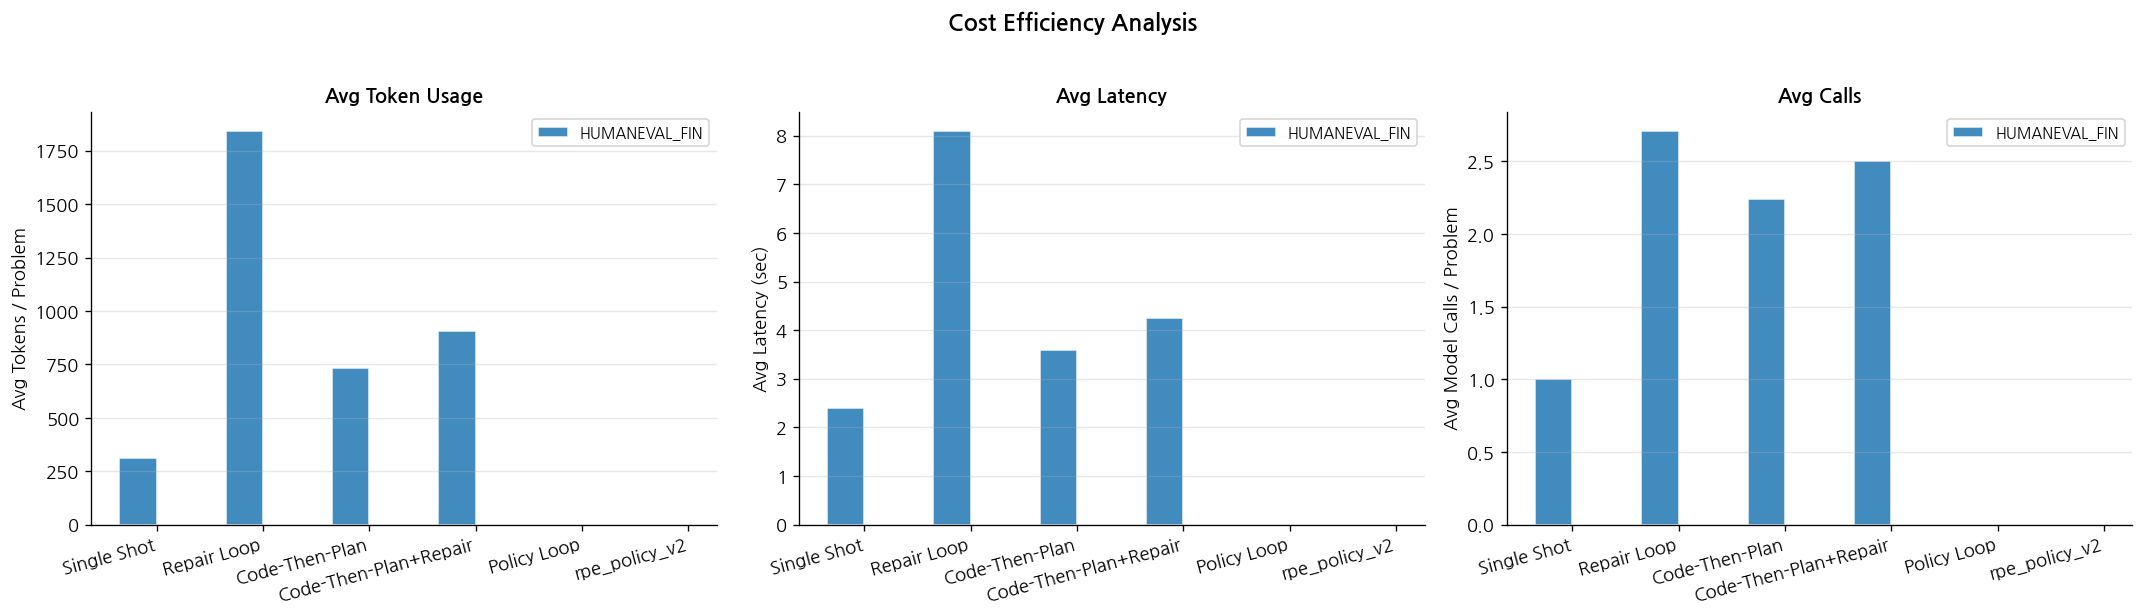


=== Efficiency Metrics Table ===


,dataset,method_label,success_metric_name,success@k,avg_tokens,avg_latency,avg_calls,success_per_1k_tokens,success_per_call
0,humaneval_fin,Single Shot,success@1,0.6951,310.6768,2.4059,1.0000,2.2374,0.6951
1,humaneval_fin,Repair Loop,success@10,0.8537,1841.0671,8.0875,2.7073,0.4637,0.3153
2,humaneval_fin,Code-Then-Plan,success@10,0.9146,735.6524,3.5982,2.2439,1.2433,0.4076
3,humaneval_fin,Code-Then-Plan+Repair,success@10,0.9207,908.7988,4.2419,2.5061,1.0131,0.3674
4,humaneval_fin,Policy Loop,success@10,0.9390,0.0000,0.0000,0.0000,0.0000,0.0000
5,humaneval_fin,rpe_policy_v2,success@10,0.9207,0.0000,0.0000,0.0000,0.0000,0.0000


In [8]:
# success@k 대비 평균 비용 효율성
eff_rows = []

for (dataset, method), s in summaries.items():
    if s is None:
        continue

    max_calls = s.get("max_calls", 10)
    success_key = s.get("success_metric_name", f"success@{max_calls}")

    success_k = s.get(
        "success_at_k",
        s.get(success_key, s.get("success@k", s.get("pass_at_1", s.get("pass@1", 0.0))))
    )

    tok = s.get("avg_tokens", 0.0)
    lat = s.get("avg_latency", 0.0)
    calls = s.get("avg_calls", 0.0)

    eff_rows.append({
        "dataset": dataset,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),
        "success_metric_name": success_key,
        "success@k": success_k,
        "avg_tokens": tok,
        "avg_latency": lat,
        "avg_calls": calls,
        "success_per_1k_tokens": (success_k / tok * 1000) if tok > 0 else 0,
        "success_per_call": (success_k / calls) if calls > 0 else 0,
    })

df_eff = pd.DataFrame(eff_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def grouped_bar(df_eff, ycol, ylabel, title, ax):
    methods_present = [m for m in METHODS if m in df_eff["method"].values]
    x = np.arange(len(methods_present))
    w = 0.35

    for di, dataset in enumerate(DATASETS):
        sub = (
            df_eff[df_eff["dataset"] == dataset]
            .set_index("method")
            .reindex(methods_present)
        )
        vals = sub[ycol].fillna(0).values
        ax.bar(
            x + di * w,
            vals,
            width=w,
            label=dataset.upper(),
            alpha=0.85,
            edgecolor="white",
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels(
        [METHOD_LABELS.get(m, m) for m in methods_present],
        rotation=15,
        ha="right",
    )
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

grouped_bar(df_eff, "avg_tokens", "Avg Tokens / Problem", "Avg Token Usage", axes[0])
grouped_bar(df_eff, "avg_latency", "Avg Latency (sec)", "Avg Latency", axes[1])
grouped_bar(df_eff, "avg_calls", "Avg Model Calls / Problem", "Avg Calls", axes[2])

plt.suptitle("Cost Efficiency Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("fig_efficiency.png", bbox_inches="tight", dpi=150)
plt.show()

print("\n=== Efficiency Metrics Table ===")
display(
    df_eff[
        [
            "dataset",
            "method_label",
            "success_metric_name",
            "success@k",
            "avg_tokens",
            "avg_latency",
            "avg_calls",
            "success_per_1k_tokens",
            "success_per_call",
        ]
    ].round(4)
)

---
## 7. Step-level 상세 분석

In [9]:
# step_logs를 하나의 DataFrame으로 합치기
step_dfs = []
for (dataset, method), steps in step_logs_all.items():
    if not steps:
        continue
    df = pd.DataFrame(steps)
    df['dataset'] = dataset
    df['method']  = method
    step_dfs.append(df)

if step_dfs:
    df_steps = pd.concat(step_dfs, ignore_index=True)
    print(f'전체 step 수: {len(df_steps):,}')
    print(f'컬럼: {list(df_steps.columns)}')
else:
    df_steps = pd.DataFrame()
    print('⚠️  step_logs 데이터 없음')

전체 step 수: 2,107
컬럼: ['run_id', 'dataset', 'problem_id', 'method', 'trajectory_id', 'step_id', 'call_index', 'candidate_id', 'stage', 'is_retry', 'is_repair', 'is_planner', 'input_tokens', 'output_tokens', 'total_tokens', 'latency_sec', 'code', 'exec_ok', 'test_pass', 'status', 'error_type', 'error_stage', 'error_message', 'tests_passed', 'tests_total', 'code_length', 'selected', 'selection_rank', 'entry_point', 'policy_action', 'planner_output', 'policy_state', 'policy_stop', 'policy_stop_reason']


In [10]:
if not df_steps.empty:
    # stage별 pass율 (generate / retry / repair / plan)
    if 'stage' in df_steps.columns and 'status' in df_steps.columns:
        df_steps['is_pass'] = df_steps['status'] == 'PASS'

        df_no_plan = df_steps[df_steps['stage'] != 'plan']  # plan step은 코드 미생성이므로 제외

        stage_pass = (
            df_no_plan
            .groupby(['dataset', 'method', 'stage'])['is_pass']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'pass_rate', 'count': 'n_steps'})
            .reset_index()
        )

        # 문제당 평균 stage 실행 횟수: problem_id별 실행 횟수를 내고 평균
        avg_per_prob = (
            df_no_plan
            .groupby(['dataset', 'method', 'stage', 'problem_id'])
            .size()                                      # 문제별 해당 stage 실행 횟수
            .reset_index(name='steps_for_this_problem')
            .groupby(['dataset', 'method', 'stage'])['steps_for_this_problem']
            .mean()                                      # 문제당 평균
            .reset_index(name='avg_steps_per_problem')
        )

        stage_pass = stage_pass.merge(avg_per_prob, on=['dataset', 'method', 'stage'], how='left')

        print('\n=== Stage별 Pass Rate (plan 제외) ===')
        print('  n_steps               : 해당 stage가 전체 실험에서 실행된 총 횟수')
        print('  avg_steps_per_problem : 해당 stage가 발생한 문제당 평균 실행 횟수')
        display(stage_pass.round(4))


=== Stage별 Pass Rate (plan 제외) ===
  n_steps               : 해당 stage가 전체 실험에서 실행된 총 횟수
  avg_steps_per_problem : 해당 stage가 발생한 문제당 평균 실행 횟수


,dataset,method,stage,pass_rate,n_steps,avg_steps_per_problem
0,humaneval_fin,code_then_plan,generate,0.6829,164,1.0000
1,humaneval_fin,code_then_plan,plan_code,0.3725,102,1.9615
2,humaneval_fin,code_then_plan_repair,generate,0.6585,164,1.0000
3,humaneval_fin,code_then_plan_repair,plan_code,0.4271,96,1.7143
4,humaneval_fin,code_then_plan_repair,repair,0.0364,55,2.3913
5,humaneval_fin,repair,generate,0.6890,164,1.0000
6,humaneval_fin,repair,repair,0.0964,280,5.4902
7,humaneval_fin,rpe_policy,generate,0.6951,164,1.0000
8,humaneval_fin,rpe_policy,plan_code,0.4118,68,1.7895
9,humaneval_fin,rpe_policy,repair,0.1714,70,2.3333


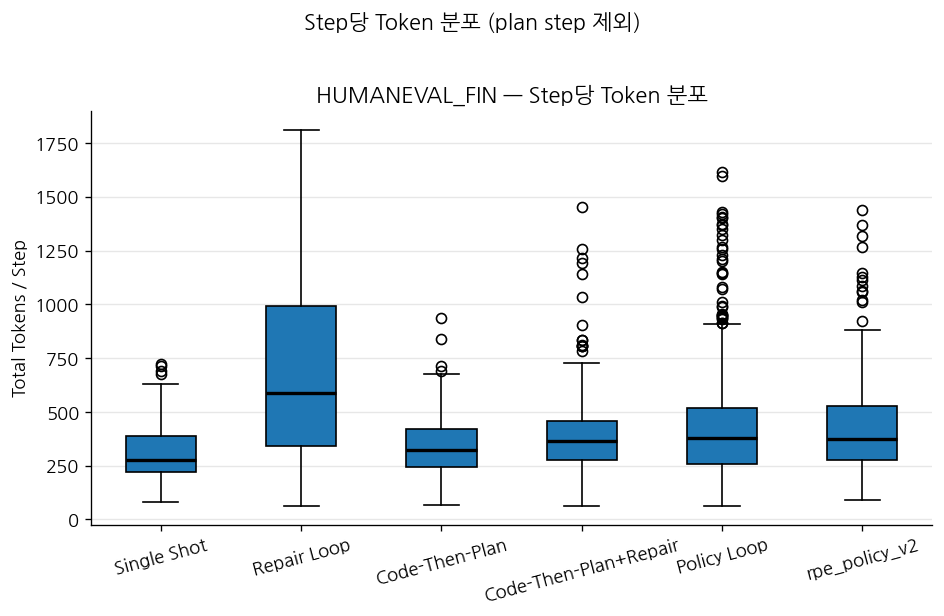

In [11]:
# step당 토큰 분포 (boxplot)
if not df_steps.empty and 'total_tokens' in df_steps.columns:
    methods_present = [m for m in METHODS if m in df_steps['method'].values]

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(8 * len(DATASETS), 5))
    if len(DATASETS) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, DATASETS):
        sub = df_steps[(df_steps['dataset'] == dataset) & (df_steps['stage'] != 'plan')]
        data = [sub[sub['method'] == m]['total_tokens'].dropna().values
                for m in methods_present if m in sub['method'].values]
        labels = [METHOD_LABELS.get(m, m) for m in methods_present if m in sub['method'].values]

        ax.boxplot(data, labels=labels, patch_artist=True,
                   medianprops=dict(color='black', linewidth=2))
        ax.set_title(f'{dataset.upper()} — Step당 Token 분포')
        ax.set_ylabel('Total Tokens / Step')
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Step당 Token 분포 (plan step 제외)', fontsize=13, y=1.02)
    plt.tight_layout()
    # plt.savefig('fig_token_dist.png', bbox_inches='tight', dpi=150)
    plt.show()

---
## 9. 종합 결론 요약

In [12]:
print('=' * 60)
print('📊 Phase 1 ver3 — 결론 요약')
print('=' * 60)

for dataset in DATASETS:
    if dataset not in df_summary.index.get_level_values('dataset'):
        continue
    sub = df_summary.loc[dataset].reindex([m for m in METHODS if m in df_summary.loc[dataset].index])

    best_pass  = sub['pass@1'].idxmax()
    best_exec  = sub['exec_success_rate'].idxmax()
    best_cond  = sub['conditional_pass'].idxmax()
    low_token  = sub['avg_tokens'].idxmin()

    print(f'\n[{dataset.upper()}]')
    print(f'  최고 pass@1          : {METHOD_LABELS.get(best_pass, best_pass):20s} ({sub.loc[best_pass, "pass@1"]:.4f})')
    print(f'  최고 exec_success    : {METHOD_LABELS.get(best_exec, best_exec):20s} ({sub.loc[best_exec, "exec_success_rate"]:.4f})')
    print(f'  최고 conditional_pass: {METHOD_LABELS.get(best_cond, best_cond):20s} ({sub.loc[best_cond, "conditional_pass"]:.4f})')
    print(f'  최소 avg_tokens      : {METHOD_LABELS.get(low_token, low_token):20s} ({sub.loc[low_token, "avg_tokens"]:.1f})')

    # single 대비 gain
    if 'single' in sub.index:
        single_p1 = sub.loc['single', 'pass@1']
        print(f'\n  Single-shot 대비 pass@1 gain:')
        for m in sub.index:
            if m == 'single':
                continue
            gain = sub.loc[m, 'pass@1'] - single_p1
            sign = '+' if gain >= 0 else ''
            print(f'    {METHOD_LABELS.get(m, m):20s}: {sign}{gain:.4f}')

print('\n' + '=' * 60)

📊 Phase 1 ver3 — 결론 요약


KeyError: 'pass@1'